In [1]:
import pandas as pd
import gspread
import re
import os
from oauth2client.service_account import ServiceAccountCredentials
from datetime import datetime

from utils import GOOGLE_SHEETS, KNOWN_BRANDS

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Librării importate și configurare completă.")

Librării importate și configurare completă.


In [2]:
def get_gspread_client(json_path='../credentials.json'):
    if not os.path.exists(json_path):
        json_path = 'credentials.json'
        
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Nu găsesc fișierul de credențiale la: {json_path}")
        
    scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
    creds = ServiceAccountCredentials.from_json_keyfile_name(json_path, scope)
    return gspread.authorize(creds)

def load_sheet_data(client, sheet_config, page_name, header_row_index=3):
    try:
        spreadsheet = client.open_by_key(sheet_config.id)
        gid_target = sheet_config.pages.get(page_name)
        
        if not gid_target or gid_target == "id":
            print(f"Skip: {page_name} (Neconfigurat)")
            return None
            
        worksheet = None
        for ws in spreadsheet.worksheets():
            if str(ws.id) == str(gid_target):
                worksheet = ws
                break
        
        if not worksheet:
            raise ValueError(f"Worksheet cu GID {gid_target} nu a fost găsit.")

        print(f"Descarc datele din: {page_name}...")
        all_values = worksheet.get_all_values()
        
        if len(all_values) <= header_row_index:
            print("Tabel gol sau header index greșit.")
            return None
            
        headers = all_values[header_row_index]
        data_rows = all_values[header_row_index + 1:]
        
        df = pd.DataFrame(data_rows, columns=headers)
        return df

    except Exception as e:
        print(f"❌ Eroare la {page_name}: {e}")
        return None

In [3]:
def clean_money(val_str):
    """Curăță string-urile de bani (ex: '1.200,50 lei' -> 1200.50)"""
    if not val_str: return 0.0
    clean = str(val_str).lower().replace('lei', '').replace('.', '').replace(',', '.').strip()
    try:
        return float(clean)
    except:
        return 0.0

def process_complex_report(raw_df):
    """Parsarea structurii ierarhice (Bon -> Produse)"""
    processed_rows = []
    
    # Starea curentă (datele bonului)
    current_bon = {
        'Nr_Comanda': None, 'Data': None, 'Pacient': None, 
        'Mod_Plata': None, 'Locatie_Bon': None
    }
    
    # Regex pentru a extrage datele din textul lung
    # Caută pattern-uri de tipul "Data: YYYY-MM-DD" sau "Pacient: NUME"
    # Ajustează regex-ul dacă formatul diferă ușor între luni
    regex_data = r"Data:\s*(\d{4}-\d{2}-\d{2})"
    regex_pacient = r"Pacient:\s*(.*?);"
    regex_comanda = r"Bon comanda:\s*(.*?);"
    regex_plata = r"Mod plata:\s*(.*)"

    for idx, row in raw_df.iterrows():
        # Verificăm coloana 'Gestiune' (unde apare textul lung)
        # Atenție: verifică numele exact al coloanei în df-ul tău (poate fi 'Gestiune' sau altceva)
        raw_text = str(row.get('Gestiune', ''))
        
        # --- LOGICA PENTRU RÂND PĂRINTE (BON) ---
        if "Bon comanda" in raw_text:
            # Extragem datele
            match_data = re.search(regex_data, raw_text)
            match_pacient = re.search(regex_pacient, raw_text)
            match_cmd = re.search(regex_comanda, raw_text)
            match_plata = re.search(regex_plata, raw_text) # Poate fi la final de text
            
            current_bon['Data'] = match_data.group(1) if match_data else None
            current_bon['Pacient'] = match_pacient.group(1).strip() if match_pacient else "Necunoscut"
            current_bon['Nr_Comanda'] = match_cmd.group(1).strip() if match_cmd else None
            
            # Uneori modul de plată e la finalul textului, după ultimul ; sau punct
            if "Numerar" in raw_text: current_bon['Mod_Plata'] = "Numerar"
            elif "Card" in raw_text: current_bon['Mod_Plata'] = "Card"
            elif "Ordin" in raw_text: current_bon['Mod_Plata'] = "OP"
            else: current_bon['Mod_Plata'] = "Nespecificat"
            
            continue # Trecem la următorul rând (care ar trebui să fie produs)

        # --- LOGICA PENTRU RÂND COPIL (PRODUS) ---
        produs_nume = str(row.get('Produs', '')).strip()
        valoare_raw = row.get('Valoare cu TVA', '') # Verifică numele coloanei!
        
        # Dacă avem un produs valid (nu e gol, nu e header repetat)
        if produs_nume and produs_nume != "Produs" and valoare_raw:
            
            valoare = clean_money(valoare_raw)
            cantitate_raw = str(row.get('Cantitate', '0')).replace(',', '.')
            try:
                cantitate = float(cantitate_raw)
            except:
                cantitate = 0

            # Construim rândul final
            new_row = {
                'Data_Incasare': current_bon['Data'],
                'Locatie': row.get('Gestiune', ''), # Locația apare de obicei pe rândul produsului
                'Nr_Bon': current_bon['Nr_Comanda'],
                'Pacient': current_bon['Pacient'],
                'Produs': produs_nume,
                'Cantitate': cantitate,
                'Valoare_Totala': valoare,
                'Mod_Plata': current_bon['Mod_Plata']
            }
            processed_rows.append(new_row)
            
    return pd.DataFrame(processed_rows)

In [4]:
def get_brand_refined_v3(text):
    text = text.upper()
    # Adăugăm branduri locale sau specifice pe care le-am văzut în datele tale
    extra_brands = [
        'CHARM', 'PREMIUM', 'MIEN', 'TRIQ', 'SUCCESS', 'POLAR', 'AVIZOR', 
        'CORSO', 'LUNETTES', 'LEVEL', 'OPT' # CORSO pare a fi brand de rame in exemplul tau
    ]
    
    # Combinăm lista ta din utils cu astea noi
    all_brands = KNOWN_BRANDS + extra_brands
    
    for brand in all_brands:
        if brand in text:
            return brand
    return "GENERIC"

def get_category_refined_v3(text, brand_found):
    text = text.upper()
    
    # 1. SERVICII
    if any(x in text for x in ["MANOPERA", "MONTAJ", "CONSULT", "DATARE", "REPARATIE", "EXAMEN"]):
        return "Servicii"

    # 2. TRATAMENTE / PICATURI / SUPLIMENTE (Update major aici)
    meds_keywords = [
        " ML", "ML ", "CPS", "PLICURI", "FOLIE", # Unitati masura
        "HYLO", "COLINERV", "KLIMI", "DROP", "SOLUTIE", "SPRAY", "TRIUM", 
        "RETINOSAN", "MACUSHIELD", "VITREOXIGEN", "THEALOZ", "BLEPHA"
    ]
    if any(x in text for x in meds_keywords):
        return "Tratamente & Solutii"

    # 3. LENTILE CONTACT (Update pentru Acuvue/Alcon)
    contact_keywords = ["CONTACT", "DAILY", "MONTHLY", "ACUVUE", "OASYS", "AIR OPTIX", "DAILIES", "BIOFINITY", " 6 BUC", "30 BUC"]
    if any(x in text for x in contact_keywords):
        return "Lentile Contact"

    # 4. ACCESORII
    if any(x in text for x in ["TOC ", "LAVETE", "SNUR", "LANT", "SERVETELE", "PATCH"]):
        return "Accesorii"

    # 5. LENTILE AERIENE (Update pentru Essilor/Hoya/Zeiss)
    lens_keywords = [
        # Cuvinte generale
        "SV ", "PC ", "BIFOCAL", "PROG", "LENTILE", 
        # Indici si materiale
        "1.5", "1.6", "1.67", "1.74", "1.59", "POLY", "TRIVEX", "ORMIX", "ORMIA",
        # Tratamente si Designuri
        "HMC", "HYDRO", "BLUE", "ARUS", "GLIDE", "SENSITY", "TRANS", "FOTOCROM",
        "CAMBER", "INNOVATOR", "CRISTALIN", "EYEZEN", "VARILUX", "VX ", "BALANSIS", "MEIRYO", "LONGHUL", "XTRACTIVE"
    ]
    if any(x in text for x in lens_keywords):
        return "Lentile Aeriene"

    # 6. RAME (Regula de Aur)
    # Dacă am găsit un Brand (chiar și unul mic gen 'CORSO') și nu e mai sus -> E RAMA
    if brand_found != "GENERIC":
        return "Rame"
    
    # 7. RAME GENERICE / ALTELE
    # Verificăm dacă e un cod scurt de ramă (ex: "AVO3190", "DG3347")
    # De obicei codurile de rame au litere urmate de cifre
    import re
    if re.search(r'[A-Z]{2,}\s*\d+', text): 
        return "Rame (Generic)"
        
    return "Altele"

In [5]:
client = get_gspread_client()

all_data_frames = []
raport_config = GOOGLE_SHEETS["Raport_incasari"]

HEADER_INDEX = 2

for month_name, gid in raport_config.pages.items():
    raw_df = load_sheet_data(client, raport_config, month_name, header_row_index=HEADER_INDEX)
    
    if raw_df is not None:
        print(f"   ... Procesez {len(raw_df)} rânduri brute...")
        clean_df = process_complex_report(raw_df)
        all_data_frames.append(clean_df)
        print(f"   ✅ Rezultat: {len(clean_df)} rânduri curate.")

if all_data_frames:
    df_final = pd.concat(all_data_frames, ignore_index=True)
    
    df_final['Brand'] = df_final['Produs'].apply(get_brand)
    df_final['Categorie'] = df_final['Produs'].apply(get_category)
    
    df_final['Data_Incasare'] = pd.to_datetime(df_final['Data_Incasare'])
    
    print("\n🎉 GATA! Datele sunt unificate.")
    display(df_final.head())
    display(df_final.info())
else:
    print("❌ Nu am putut procesa nicio lună.")

Descarc datele din: Incasari_Iunie_2025...
   ... Procesez 7340 rânduri brute...
   ✅ Rezultat: 5392 rânduri curate.
Descarc datele din: Incasari_Mai_2025...
   ... Procesez 8981 rânduri brute...
   ✅ Rezultat: 6635 rânduri curate.
Descarc datele din: Incasari_Aprilie_2025...
   ... Procesez 7594 rânduri brute...
   ✅ Rezultat: 5630 rânduri curate.
Descarc datele din: Incasari_Martie_2025...
   ... Procesez 9663 rânduri brute...
   ✅ Rezultat: 7169 rânduri curate.
Descarc datele din: Incasari_Februarie_2025...
   ... Procesez 8222 rânduri brute...
   ✅ Rezultat: 6109 rânduri curate.
Descarc datele din: Incasari_Ianuarie_2025...
   ... Procesez 8715 rânduri brute...
   ✅ Rezultat: 6501 rânduri curate.


NameError: name 'get_brand' is not defined

<Axes: title={'center': 'Top Încasări pe Locații'}, ylabel='Locatie'>

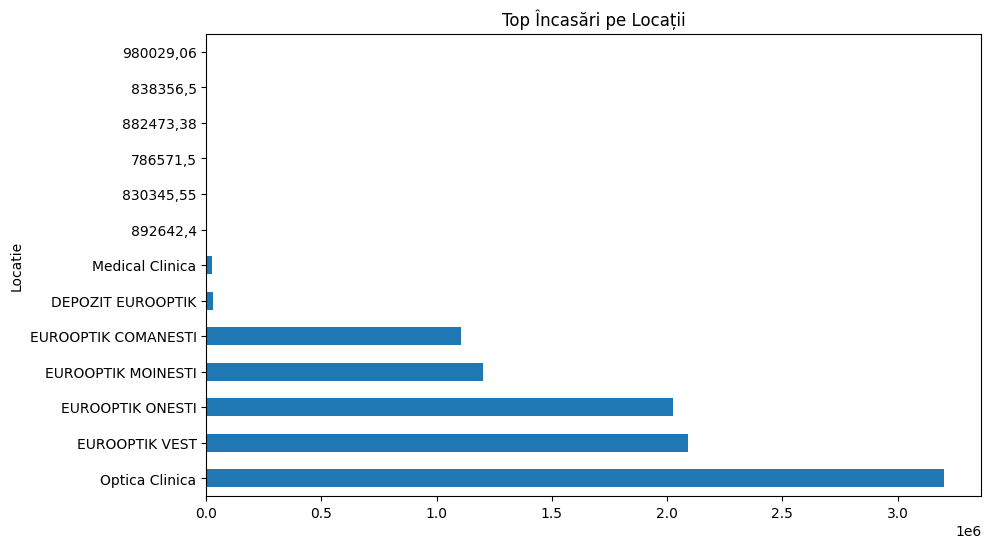

In [ ]:
# Verificăm total încasări pe locații
summary = df_final.groupby('Locatie')['Valoare_Totala'].sum().sort_values(ascending=False)
summary.plot(kind='barh', title="Top Încasări pe Locații", figsize=(10, 6))

In [ ]:
# Varianta 1: CSV (cel mai sigur pt upload manual)
filename = f"export_incasari_optica_{datetime.now().strftime('%Y%m%d')}.csv"
df_final.to_csv(filename, index=False)
print(f"Fișier salvat: {filename}")

# Varianta 2: Upload înapoi în Google Sheets (într-un sheet nou 'Master_Data')
# Necesită cod extra pentru clear sheet + update, pot să ți-l dau dacă vrei.

Fișier salvat: export_incasari_optica_20251217.csv


In [ ]:
# 1. Recalculăm Brand-ul (am adăugat CORSO și altele)
df_final['Brand'] = df_final['Produs'].apply(get_brand_refined_v3)

# 2. Recalculăm Categoria
df_final['Categorie'] = df_final.apply(lambda row: get_category_refined_v3(row['Produs'], row['Brand']), axis=1)

# 3. Verificăm liniile care erau problematice
test_products = [
    "VX XR ORMIX 1.6 CP TRANS GRI", 
    "ACUVUE OASYS FOR ASTIGMATISM", 
    "RETINOSAN 30CP", 
    "EMPORIO ARMANI EA1027",
    "CORSO 249"
]

print("--- Testare pe produsele tale ---")
for p in test_products:
    b = get_brand_refined_v3(p)
    c = get_category_refined_v3(p, b)
    print(f"Produs: {p[:20]}... -> Brand: {b} | Categ: {c}")

print("\n--- Statistici Noi ---")
print(df_final['Categorie'].value_counts())

--- Testare pe produsele tale ---
Produs: VX XR ORMIX 1.6 CP T... -> Brand: GENERIC | Categ: Lentile Aeriene
Produs: ACUVUE OASYS FOR AST... -> Brand: GENERIC | Categ: Lentile Contact
Produs: RETINOSAN 30CP... -> Brand: GENERIC | Categ: Tratamente & Solutii
Produs: EMPORIO ARMANI EA102... -> Brand: EMPORIO ARMANI | Categ: Rame
Produs: CORSO 249... -> Brand: CORSO | Categ: Rame

--- Statistici Noi ---
Categorie
Lentile Aeriene         7622
Servicii                6896
Tratamente & Solutii    6212
Rame                    5725
Accesorii               4073
Rame (Generic)          3625
Altele                  2951
Lentile Contact          332
Name: count, dtype: int64
